In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import *

from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness import *

CPU Num Cores: 30


/home/dutra/dev/eztaox/qvc/hubble_utils.py:1024: SyntaxWarning: invalid escape sequence '\p'
  If True, values are strings like r"$x \pm y$". Otherwise tuples (mean, std).


In [2]:
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = load_pantheon_data()
#df_agn = load_agn_data("results/data/aug29_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4_fittedm2500_diffalpha.h5")
#df_agn = load_agn_data("results/data/aug31_chisq_alphalamcsv_nobwb_poly1_N20w4000s1000t8c4_fittedm2500.h5")
df_agn = load_agn_data("results/data/sep1_chisq_alphalamcsv_nobwb_poly1_N20w4000s1000t8c4_fittedm2500_twice.h5")

#df_agn = df_agn.tail(2000)
#df_agn = df_agn[:2000]


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Data loaded. 


Reading quasars from HDF5: 100%|██████████| 4000/4000 [00:10<00:00, 396.24it/s]


Number of quasars loaded: 4000
spectra_fit_csv not provided, assuming alpha_lambda is in agn h5 file
[WARNING] cov_log_sigma_UV_log_tau_UV_RF not in data, setting to 0.0
Number of quasars with 0 < z <= 1.0: 989
Number of quasars with z > 3: 116
Highest redshift quasar: 4.32306007971774
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Excluding 1 objects by object_id exclusion list
Cut on log_tau_UV_RF: 31 objects removed
Cut on redchi: 47 objects removed
Cut on apparent_mag_2500: 74 objects removed
Cut on apparent_mag_i: 34 objects removed
Removing 0 objects with NaN in column 'alpha_lambda'
Removing 0 objects with NaN in column 'alpha_lambda_err'
Total objects removed by all cuts: 151
Number of quasars with 0 < z <= 1.0: 918
Number of dropped quasars with 0 < z <= 1.0: 71
Number of quasars with 

In [16]:
cosmo_model_2 = "Flatw0waCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_2, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/sept3_priya/dynesty_checkpoint_{cosmo_model_2}_joint_test.save",
                    only_sna=False, speed="test")
sampler, flat_samples_2, model_labels, dmag_corr, logZ, logZerr, debiased_residuals_2 = r

Running sampling with 9 parameters for cosmological model: Flatw0waCDM
object_id for m2500 > 25: ['024629.37+000735.3' '024508.67+003710.6' '004351.22+004617.4'
 '230319.92+001600.2' '220632.21+011054.1']
Best alpha selected by CV: 0.01747528400007685
a (slope on mag_i)      = 1.035955 ± 0.005861
b (slope on alpha)      = 1.230627 ± 0.010187
d (quad term on mag_i)  = 0.008347 ± 0.002676
c_pivot (at pivots)     = 22.467893 ± 0.005761
c (intercept)           = -0.752922
R^2                     = 0.8934
Scatter (σ)             = 0.301 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.7720
log tau UV RF pivot (weighted): 2.6912
log sigma0 mea

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept3_priya/dynesty_checkpoint_Flatw0waCDM_joint_test.save

Bayesian evidence logZ = 5733.59 ± 0.70

Highest-weight (posterior) sample:
  idx: 6465
  logl: 5761.477783691391
  weight: 0.005353143512279943
  (preview) integrals[:10]: [0.07338669 0.04819315 0.06193933 0.05326778 0.05429829 0.01648584
 0.07174141 0.08414527 0.10589447 0.0595869 ]

Dynesty results stats:
  samples shape: (6466, 9)
  blobs shape: (6466, 2, 3848)
  weights max: 0.005353143512279943
  effective samples (ESS): 1048.1900106918063
  resampled samples shape: (6466, 9)
  resampled blobs shape: (6466, 2, 3848)

Median parameters (equal-weight posterior):
[-19.24781063 -21.12036051   6.22598034  -3.05749791  -0.38743105
  72.84778035   0.52198664  -0.78611426  -8.88893534]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.6787984351036664
Saving plots to  plots/hubble//Flatw0waCDM_joint_test
Plotting full dynes

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:630: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.30 | object_id: 1390061 | SDSS: 024508.67+003710.6 | RA: 41.28616 | DEC: 0.61963 | Residual: 4.8
	z: 0.38 | object_id: 1400251 | SDSS: 021713.10+004107.2 | RA: 34.30462 | DEC: 0.68534 | Residual: 4.0
	z: 0.74 | object_id: 1413455 | SDSS: 013824.21+002851.6 | RA: 24.60091 | DEC: 0.48102 | Residual: 4.3
	z: 0.30 | object_id: 1424781 | SDSS: 010417.81-005317.0 | RA: 16.07421 | DEC: -0.88806 | Residual: 6.3
	z: 0.21 | object_id: 1426470 | SDSS: 005857.19+010641.7 | RA: 14.73830 | DEC: 1.11159 | Residual: 6.7
	z: 2.08 | object_id: 1426960 | SDSS: 005716.12-010524.4 | RA: 14.31720 | DEC: -1.09013 | Residual: 4.1
	z: 1.91 | object_id: 1430667 | SDSS: 004526.85-003304.6 | RA: 11.36191 | DEC: -0.55128 | Residual: -4.6
	z: 0.48 | object_id: 1431196 | SDSS: 004351.22+004617.4 | RA: 10.96345 | DEC: 0.77151 | Residual: 4.8
	z: 0.25 | object_id: 1452568 | SDSS: 230319.92+001600.2 | RA: 345.83302 | DEC: 0.26

In [4]:

cosmo_model = "FlatwCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/sept3_priya/dynesty_checkpoint_{cosmo_model}_joint_test.save",
                    only_sna=False, speed="test")
sampler, flat_samples, model_labels, dmag_corr, logZ, logZerr, debiased_residuals = r

Running sampling with 8 parameters for cosmological model: FlatwCDM
object_id for m2500 > 25: ['024629.37+000735.3' '024508.67+003710.6' '004351.22+004617.4'
 '230319.92+001600.2' '220632.21+011054.1']
Best alpha selected by CV: 0.01747528400007685
a (slope on mag_i)      = 1.035955 ± 0.005861
b (slope on alpha)      = 1.230627 ± 0.010187
d (quad term on mag_i)  = 0.008347 ± 0.002676
c_pivot (at pivots)     = 22.467893 ± 0.005761
c (intercept)           = -0.752922
R^2                     = 0.8934
Scatter (σ)             = 0.301 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.7720
log tau UV RF pivot (weighted): 2.6912
log sigma0 mean: 

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept3_priya/dynesty_checkpoint_FlatwCDM_joint_test.save

Bayesian evidence logZ = 5737.15 ± 0.66

Highest-weight (posterior) sample:
  idx: 4807
  logl: 5760.324512827344
  weight: 0.005893404056260403
  (preview) integrals[:10]: [0.06825078 0.04342642 0.05929824 0.04970598 0.05037043 0.01548716
 0.06797644 0.08099823 0.10490144 0.05604003]

Dynesty results stats:
  samples shape: (4808, 8)
  blobs shape: (4808, 2, 3848)
  weights max: 0.005893404056260403
  effective samples (ESS): 903.0185571220844
  resampled samples shape: (4808, 8)
  resampled blobs shape: (4808, 2, 3848)

Median parameters (equal-weight posterior):
[-19.24754274 -21.1257715    6.3191655   -3.09526262  -0.38191251
  73.46843634   0.39679948  -1.17068351]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.6825547674484761
Saving plots to  plots/hubble//FlatwCDM_joint_test
Plotting full dynesty corner...
Plottin

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:630: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.30 | object_id: 1390061 | SDSS: 024508.67+003710.6 | RA: 41.28616 | DEC: 0.61963 | Residual: 4.8
	z: 0.38 | object_id: 1400251 | SDSS: 021713.10+004107.2 | RA: 34.30462 | DEC: 0.68534 | Residual: 4.1
	z: 0.74 | object_id: 1413455 | SDSS: 013824.21+002851.6 | RA: 24.60091 | DEC: 0.48102 | Residual: 4.3
	z: 0.30 | object_id: 1424781 | SDSS: 010417.81-005317.0 | RA: 16.07421 | DEC: -0.88806 | Residual: 6.4
	z: 0.21 | object_id: 1426470 | SDSS: 005857.19+010641.7 | RA: 14.73830 | DEC: 1.11159 | Residual: 6.7
	z: 2.08 | object_id: 1426960 | SDSS: 005716.12-010524.4 | RA: 14.31720 | DEC: -1.09013 | Residual: 4.2
	z: 1.91 | object_id: 1430667 | SDSS: 004526.85-003304.6 | RA: 11.36191 | DEC: -0.55128 | Residual: -4.6
	z: 0.48 | object_id: 1431196 | SDSS: 004351.22+004617.4 | RA: 10.96345 | DEC: 0.77151 | Residual: 4.9
	z: 0.25 | object_id: 1452568 | SDSS: 230319.92+001600.2 | RA: 345.83302 | DEC: 0.26

In [ ]:
def plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model, z_pivot_agn, plot_path="plots/hubble/",
                show_binned_agn=True,
                debias=False, dms=None, show=False, completeness=True, show_true=False, verbose=True,
                cosmo_model_residual=None):
    """
    Hubble diagram (Pantheon+-style):
      • Model line + 68% band in magenta
      • Concordance ΛCDM in black
      • SN Ia in blue
      • AGN points + error bars (solid if 0.44<=z<=3.16 else open)
      • Main: AGN binned in linear z
      • Inset: AGN binned in log z (matches inset x-scale)
    If residuals_2 is provided, the residuals panel overlays a solid line of (residuals - residuals_2).
    Returns: residuals, mu_pred_median, mu_pred_std
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from astropy.cosmology import FlatLambdaCDM, FlatwCDM, Flatw0waCDM
    from scipy.ndimage import uniform_filter1d
    # Ensure your project provides these:
    # from your_module import FlatwpwaCDM, M_model_agn, M_model_agn_err, get_model_params, make_dm_function
    # (FlatwpwaCDM expected if using 'FlatwpwaCDM')

    # --- Labels ---
    if   cosmo_model == 'FlatwCDM':      label = r"Flat$w$CDM model"
    elif cosmo_model == 'Flatw0waCDM':   label = r"Flat$w_0w_a$CDM model"
    elif cosmo_model == 'FlatLambdaCDM': label = r"Flat$\Lambda$CDM model"
    elif cosmo_model == 'FlatwpwaCDM':   label = r"Flat$w_p\!-\!w_a$CDM model"
    else:
        raise ValueError("Invalid cosmology model.")

    # --- Thinning for speed (cap to ~500 samples) ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    z_grid = np.linspace(1e-4, 5.2, 250)

    # --- Parameter bookkeeping ---
    _, model_labels, _ = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Small helper: μ_model(z | params) ---
    def _mu_model(model_name, params_dict, z, zp):
        if model_name == 'FlatwCDM':
            return FlatwCDM(H0=params_dict['H0'], Om0=params_dict['Om0'], w0=params_dict['w0']).distmod(z).value
        elif model_name == 'Flatw0waCDM':
            return Flatw0waCDM(H0=params_dict['H0'], Om0=params_dict['Om0'],
                               w0=params_dict['w0'], wa=params_dict['wa']).distmod(z).value
        elif model_name == 'FlatLambdaCDM':
            return FlatLambdaCDM(H0=params_dict['H0'], Om0=params_dict['Om0']).distmod(z).value
        elif model_name == 'FlatwpwaCDM':
            return FlatwpwaCDM(H0=params_dict['H0'], Om0=params_dict['Om0'],
                               wp=params_dict['wp'], wa=params_dict['wa'], zp=zp).distmod(z).value
        else:
            raise ValueError("Invalid cosmology model for _mu_model().")

    # --- Cosmology band on grid from posterior samples ---
    mu_models = np.array([
        _mu_model(
            cosmo_model,
            {k: s[param_indices[k]] for k in model_labels},
            z_grid, z_pivot_agn
        )
        for s in flat_samples
    ])
    mu_model_16th   = np.percentile(mu_models, 16, axis=0)
    mu_model_median = np.percentile(mu_models, 50, axis=0)
    mu_model_84th   = np.percentile(mu_models, 84, axis=0)

    # Median params (also used later)
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}

    # --- Predicted AGN μ per object ---
    m_obs = df_agn['apparent_mag_2500'].values
    mu_pred_samples = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        agn_params_arr = agn_model_pack_params(sample_params)
        agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(df_agn)

        predicted_M2500 = M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
        predicted_M2500_err = M_model_agn_err(agn_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
        mu_pred_samples.append(m_obs - predicted_M2500)
    mu_pred_samples = np.array(mu_pred_samples)

    # De-bias (assumes your make_dm_function clips to grid, no extrapolation)
    if debias:
        dm_interp = make_dm_function(m_obs, df_agn['z'], dms, method='linear')
        pts = np.column_stack([df_agn['z'].values, m_obs])
        mu_pred_samples -= dm_interp(pts)

    mu_pred_median = np.percentile(mu_pred_samples, 50, axis=0)
    mu_pred_16th   = np.percentile(mu_pred_samples, 16, axis=0)
    mu_pred_84th   = np.percentile(mu_pred_samples, 84, axis=0)

    # Per-object uncertainty (for yerr)
    agn_params_arr = agn_model_pack_params(results)
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(df_agn)
    predicted_M2500 = M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
    predicted_M2500_err = M_model_agn_err(agn_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)

    mu_pred_std = np.sqrt(
        df_agn['apparent_mag_2500_err'].values**2 +
        (0.055 * df_agn["z"].values)**2 +
        predicted_M2500_err**2
    )

    # Residuals (vs. median μ_model)
    mu_interp = np.interp(df_agn["z"].values, z_grid, mu_model_median)
    residuals = mu_pred_median - mu_interp

    # ----------------- BINNING -----------------
    def _weighted_bin_stats(z, y, w, bins, *, min_count=3, center='weighted'):
        idx = np.digitize(z, bins)  # (bins[i-1], bins[i]]
        zs, means, sems = [], [], []
        for i in range(1, len(bins)):
            m = (idx == i)
            if m.sum() >= min_count:
                wi, yi, zi = w[m], y[m], z[m]
                wsum = wi.sum()
                means.append(np.sum(wi * yi) / wsum)
                sems.append(np.sqrt(1.0 / wsum))  # SE of weighted mean
                if center == 'weighted':
                    zs.append(np.average(zi, weights=wi))
                elif center == 'geom':
                    zs.append(np.sqrt(bins[i-1] * bins[i]))
                else:
                    zs.append(0.5 * (bins[i-1] + bins[i]))
        return np.asarray(zs), np.asarray(means), np.asarray(sems)

    # Weights for AGN
    w = 1.0 / np.square(mu_pred_std)

    # Linear-z bins for MAIN & RESIDUALS panel
    dz   = 0.2
    zmax_main = 3.8
    bins_linear = np.arange(0.05, zmax_main + dz + 1e-9, dz)
    z_lin, mu_lin_mean, mu_lin_sem = _weighted_bin_stats(
        df_agn["z"].values, mu_pred_median, w, bins_linear, min_count=3, center='weighted'
    )

    # NEW: binned residuals (linear-z), used in residual panel
    z_res_lin, resid_lin_mean, resid_lin_sem = _weighted_bin_stats(
        df_agn["z"].values, residuals, w, bins_linear, min_count=3, center='weighted'
    )

    # Log-z bins for INSET (match inset xscale='log')
    zpos = df_agn["z"].values[df_agn["z"].values > 0]
    zmin_inset = max(0.02, float(np.min(zpos))) if zpos.size else 0.02
    zmax_inset = 3.8
    bins_per_decade = 6
    decades = np.log10(zmax_inset) - np.log10(zmin_inset)
    n_bins_log = max(1, int(np.ceil(decades * bins_per_decade)))
    bins_log = np.logspace(np.log10(zmin_inset), np.log10(zmax_inset), n_bins_log + 1)
    z_log, mu_log_mean, mu_log_sem = _weighted_bin_stats(
        df_agn["z"].values, mu_pred_median, w, bins_log, min_count=3, center='weighted'
    )

    # ======== Plot ========
    fig = plt.figure(figsize=(9, 7))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.06)
    ax = fig.add_subplot(gs[0])
    ax.set_ylim(26, 51)
    ax.set_xlim(-0.2, 4.2)
    inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)
    ax_resid = fig.add_subplot(gs[1], sharex=ax)

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = df_agn["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # ---------- Inset (log-z) ----------
    inset_ax.set_xscale('log')

    # AGN (inside)
    inset_ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=2,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=0.8,
        alpha=0.7, zorder=1, label="AGN"
    )
    # AGN (outside, open)
    inset_ax.errorbar(
        df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
        fmt='o', linestyle='none', markersize=2, mfc='none', mec="k", alpha=0.70,
        ecolor="#666666", elinewidth=0.8, zorder=1
    )

    # INSET: log-binned AGN
    if show_binned_agn:
        inset_ax.errorbar(
            z_log, mu_log_mean, yerr=mu_log_sem,
            fmt='o', linestyle='none',
            markersize=3, mfc='red', mec='none',
            ecolor='red', elinewidth=2.2, capsize=3.5,
            alpha=0.98, zorder=14, label="AGN (z-binned, log)"
        )

    # SN Ia
    inset_ax.errorbar(
        df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
        fmt='s', markersize=2, color="#0A84FF", linestyle='none', lw=0.8, alpha=0.7, zorder=1, label="SN Ia"
    )

    # Model + band
    inset_ax.plot(z_grid, mu_model_median, color="m", lw=1.4, alpha=1.0, zorder=5, label=label)
    inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.22, zorder=4)

    # Concordance (compute once)
    mu_conc = FlatLambdaCDM(H0=70, Om0=0.3).distmod(z_grid).value
    inset_ax.plot(z_grid, mu_conc, color="#F0B000", lw=1.2, ls='--', alpha=0.9, label=r"Concordance $\Lambda$CDM")

    inset_ax.set_xlim(0.02, 5.2)
    inset_ax.set_ylim(32, 51)
    inset_ax.set_xlabel(r"$z$", fontsize=12, labelpad=-10)
    inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
    inset_ax.tick_params(axis='both', which='major', labelsize=10)

    # ---------- Main plot ----------
    # AGN (inside)
    ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0, label="AGN"
    )
    # AGN (outside, open)
    ax.errorbar(
        df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
        fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
        ecolor="#666666", elinewidth=1.1, zorder=0
    )

    # MAIN: linear-binned AGN
    if show_binned_agn:
        ax.errorbar(
            z_lin, mu_lin_mean, yerr=mu_lin_sem,
            fmt='o', linestyle='none',
            markersize=5, mfc='red', mec='none',
            ecolor='red', elinewidth=2.2, capsize=3.5,
            alpha=0.98, zorder=14, label="AGN (z-binned)"
        )

    # SN Ia
    ax.errorbar(
        df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
        fmt='s', markersize=2, color="#0A84FF", linestyle='none', lw=0.8, alpha=0.7, zorder=1, label="SN Ia"
    )

    # Model + 68% band
    ax.plot(z_grid, mu_model_median, color="m", lw=2.4, alpha=1.0, zorder=5, label=label)
    ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.25, zorder=4)

    # Survey magnitude limit (shade above)
    if completeness and not debias:
        agn_params_arr = agn_model_pack_params(results)
        agn_obs_med = dict(
            log_sigma_UV    = float(np.median(df_agn['log_sigma_UV'].values)) * np.ones_like(z_grid),
            log_sigma_UV_err = float(np.median(df_agn['log_sigma_UV_err'].values)) * np.ones_like(z_grid),
            log_tau_UV_RF = float(np.median(df_agn['log_tau_UV_RF'].values)) * np.ones_like(z_grid),
            log_tau_UV_RF_err = float(np.median(df_agn['log_tau_UV_RF_err'].values)) * np.ones_like(z_grid),
            alpha_nu     = float(np.median(df_agn['alpha_nu'].values)) * np.ones_like(z_grid),
            alpha_nu_err = float(np.median(df_agn['alpha_nu_err'].values)) * np.ones_like(z_grid),
            cov_log_sigma_UV_log_tau_UV_RF = float(np.median(df_agn['cov_log_sigma_UV_log_tau_UV_RF'].values)) * np.ones_like(z_grid),
        )
        agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(agn_obs_med)

        M_med_grid = np.median([
            M_model_agn(agn_params_arr, agn_obs_arr, agn_pivot_arr)
            for s in flat_samples
        ], axis=0)

        m_lim = 24.0
        mu_lim = m_lim - M_med_grid
        ax.fill_between(z_grid, mu_lim, 60, color="red", alpha=0.15, zorder=2, label="< 50% complete")
        inset_ax.fill_between(z_grid, mu_lim, 60, color="red", alpha=0.12, zorder=2, label="< 50% complete")

    # Concordance ΛCDM (reuse computed)
    ax.plot(z_grid, mu_conc, color="#F0B000", lw=1.6, ls='--', alpha=0.9, label=r"Concordance $\Lambda$CDM")

    # Labels, ticks, legend
    ax.set_ylabel(r"$\mu$ (mag)")
    ax.set_xlabel(r"$z$")
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.22, 0.06), fontsize=12)

    # ---------- Residuals panel ----------
    # AGN residuals (inside)
    ax_resid.errorbar(
        df_agn["z"][mask_in], residuals[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0
    )
    # AGN residuals (outside)
    ax_resid.errorbar(
        df_agn["z"][mask_out], residuals[mask_out], yerr=mu_pred_std[mask_out],
        fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
        ecolor="#666666", elinewidth=1.1, zorder=0
    )
    # Zero line
    ax_resid.axhline(0.0, color="#999999", lw=1.0, ls='--', zorder=1)

    # NEW: binned residuals in red (points + thin connecting line)
    if z_res_lin.size:
        ax_resid.errorbar(
            z_res_lin, resid_lin_mean, yerr=resid_lin_sem,
            fmt='o', linestyle='none', markersize=5,
            mfc='red', mec='none', ecolor='red', elinewidth=2.0, capsize=3.0,
            alpha=0.98, zorder=15
        )
        #ax_resid.plot(z_res_lin, resid_lin_mean, lw=1.2, color='red', alpha=0.9, zorder=14)

    # Optional: line for (residuals - residuals_2) using median params of each model
    if cosmo_model_residual is not None:
        z_grid_fine = np.linspace(1e-4, 5.2, 500)
        cosmo_model_2, flat_samples_2 = cosmo_model_residual
        _, model_labels_2, _ = get_model_params(cosmo_model_2)
        results_2 = {key: np.median(flat_samples_2[:, i]) for i, key in enumerate(model_labels_2)}

        mu_model_1 = _mu_model(cosmo_model, results,   z_grid_fine, z_pivot_agn)
        mu_model_2 = _mu_model(cosmo_model_2, results_2, z_grid_fine, z_pivot_agn)
        ax_resid.plot(z_grid_fine, mu_model_1 - mu_model_2, lw=2.2, color="m", alpha=0.95)

    ax_resid.set_ylabel(r"$\Delta\mu$ (mag)")
    ax_resid.set_xlabel(r"$z$")
    ax_resid.set_ylim(-.5, .5)

    for axi in (ax, inset_ax, ax_resid):
        axi.minorticks_on()
        axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
        axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)

    # Hide the main panel's x-axis labels, numbers, and ticks (leave residuals' x-axis intact)
    ax.set_xlabel("")  # remove main x-axis label
    ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False, top=False)
    ax.xaxis.offsetText.set_visible(False)  # hide any scientific-notation offset text

    # Save/show
    fig.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    filename = "hubble_diagram_debiased.png" if debias else "hubble_diagram.png"
    plt.savefig(os.path.join(plot_path, filename))
    if show:
        plt.show()
    plt.close(fig)

    # Residual Outlier report
    outlier_mask = np.abs(residuals) > 4
    if np.any(outlier_mask) and verbose:
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        print("Outliers with residuals > 4:")
        for idx in np.where(outlier_mask)[0]:
            sdss_name = df_agn.iloc[idx].get('sdss_name', 'Unknown')
            object_id = df_agn.iloc[idx].get('object_id', 'Unknown')
            ra  = df_agn.iloc[idx].get('ra',  np.nan)
            dec = df_agn.iloc[idx].get('dec', np.nan)
            z   = df_agn.iloc[idx]['z']
            print(f"\tz: {z:.2f} | object_id: {object_id} | SDSS: {sdss_name} | RA: {ra:.5f} | DEC: {dec:.5f} | Residual: {residuals[idx]:.1f}")

    # Standard deviation Outlier report
    outlier_mask = mu_pred_std > 4
    if np.any(outlier_mask) and verbose:
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        print("Outliers with mu_pred_std > 4:")
        for idx in np.where(outlier_mask)[0]:
            sdss_name = df_agn.iloc[idx].get('sdss_name', 'Unknown')
            object_id = df_agn.iloc[idx].get('object_id', 'Unknown')
            ra  = df_agn.iloc[idx].get('ra',  np.nan)
            dec = df_agn.iloc[idx].get('dec', np.nan)
            z   = df_agn.iloc[idx]['z']
            print(f"\tz: {z:.2f} | object_id: {object_id} | SDSS: {sdss_name} | RA: {ra:.5f} | DEC: {dec:.5f} | Residual: {residuals[idx]:.1f}")

    return residuals, mu_pred_median, mu_pred_std


/tmp/ipykernel_1054765/3659830801.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


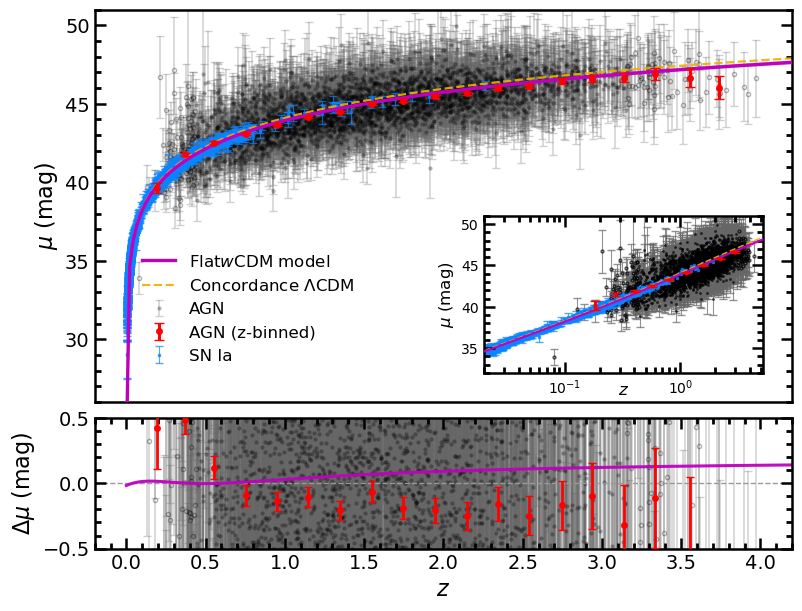

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.30 | object_id: 1390061 | SDSS: 024508.67+003710.6 | RA: 41.28616 | DEC: 0.61963 | Residual: 4.8
	z: 0.38 | object_id: 1400251 | SDSS: 021713.10+004107.2 | RA: 34.30462 | DEC: 0.68534 | Residual: 4.0
	z: 0.74 | object_id: 1413455 | SDSS: 013824.21+002851.6 | RA: 24.60091 | DEC: 0.48102 | Residual: 4.3
	z: 0.30 | object_id: 1424781 | SDSS: 010417.81-005317.0 | RA: 16.07421 | DEC: -0.88806 | Residual: 6.3
	z: 0.21 | object_id: 1426470 | SDSS: 005857.19+010641.7 | RA: 14.73830 | DEC: 1.11159 | Residual: 6.7
	z: 2.08 | object_id: 1426960 | SDSS: 005716.12-010524.4 | RA: 14.31720 | DEC: -1.09013 | Residual: 4.1
	z: 1.91 | object_id: 1430667 | SDSS: 004526.85-003304.6 | RA: 11.36191 | DEC: -0.55128 | Residual: -4.7
	z: 0.48 | object_id: 1431196 | SDSS: 004351.22+004617.4 | RA: 10.96345 | DEC: 0.77151 | Residual: 4.8
	z: 0.25 | object_id: 1452568 | SDSS: 230319.92+001600.2 | RA: 345.83302 | DEC: 0.26

(array([-1.20055904, -0.41582816, -1.44614004, ..., -0.50633987,
        -0.85905296,  0.85052378], shape=(3848,)),
 array([44.04879084, 44.67228627, 42.47155567, ..., 44.6413953 ,
        42.5683063 , 47.09668232], shape=(3848,)),
 array([1.46466294, 1.43696822, 1.24701967, ..., 1.58475285, 1.43206063,
        2.21132558], shape=(3848,)))

In [34]:
#residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, verbose=False, show_true=False)

plot_hubble(flat_samples, df_agn, df_pantheon, 
                cosmo_model="FlatwCDM", z_pivot_agn=1.5,
                show_true=False, show=True, debias=True, dms=dmag_corr, plot_path='plots/hubble/test',
                cosmo_model_residual=(cosmo_model_2, flat_samples_2))

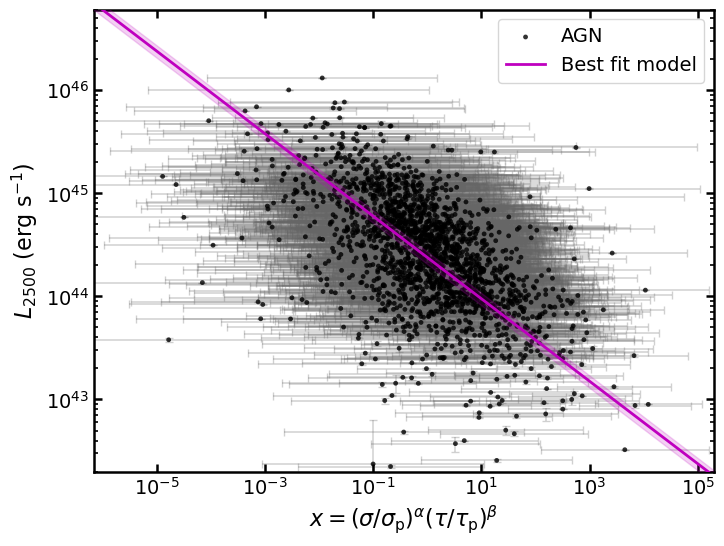

In [14]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    def compute_xlog_and_err(params_arr, obs_arr, err_arr, pivots_array):
        # --- params ---
        alpha_agn      = params_arr[agn_model_pidx["alpha_agn"]]
        beta_agn       = params_arr[agn_model_pidx["beta_agn"]]

        # --- observables ---
        log_sigma   = obs_arr[agn_model_oidx["log_sigma_UV"]]
        log_tau     = obs_arr[agn_model_oidx["log_tau_UV_RF"]]
        alpha_nu    = obs_arr[agn_model_oidx["alpha_nu"]]

        # --- pivots ---
        log_sigma_p = pivots_array[agn_model_oidx["log_sigma_UV"]]
        log_tau_p   = pivots_array[agn_model_oidx["log_tau_UV_RF"]]

        # Centered predictors
        dx = (log_sigma - log_sigma_p)
        dy = (log_tau   - log_tau_p)

        # --- Full predictor in log10 ---
        x_log = (
            alpha_agn * dx
            + beta_agn  * dy
        )


        x_log_err = M_model_agn_err(params_arr, obs_arr, err_arr, pivots_array)


        return x_log, x_log_err

    # --- Posterior medians (for cosmology & placing data in x) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional debias) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        actual_M2500 -= dm_interp(pts)
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # y measurement uncertainty from apparent magnitudes (propagated into log10 L)
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- x for data (full predictor) ---
    median_params_arr = agn_model_pack_params(results)
    x_log_data, x_log_err_data = compute_xlog_and_err(median_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_data = 10**x_log_data
    x_lower = 10**(x_log_data - x_log_err_data)
    x_upper = 10**(x_log_data + x_log_err_data)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Grid for model curves/band ---
    lo = np.percentile(x_log_data - x_log_err_data, 0) - 0.05
    hi = np.percentile(x_log_data + x_log_err_data, 100) + 0.05
    x_log_grid = np.linspace(lo, hi, 200)
    x_grid = 10**x_log_grid

    # --- Predict logL on grid for each posterior sample (we'll only use quantiles + median line) ---
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        aparr = agn_model_pack_params(sample_params)
        M0 = aparr[agn_model_pidx["M0_agn"]]
        b = -0.4 * (M0 - 90.0)
        ylog_grid_by_sample.append(b + (-0.4) * x_log_grid)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)

    # --- Residuals vs median model (log space) ---
    from scipy.interpolate import interp1d
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_data)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_data) - f_low(x_log_data))
    propagated_err = 0.4 * np.abs(x_log_err_data)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    import matplotlib.gridspec as gridspec
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with x & y error bars (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    ax.scatter(
        x_data, 10**actual_logL2500,
        s=12, c="black", marker="o", edgecolors="none", alpha=0.8, zorder=1, label="AGN"
    )
    ax.errorbar(
        x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
        fmt='none', linestyle='none',
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0
    )
    # --- Model: one line (median) + 68% band ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.18, zorder=9,)
    ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='Best fit model')

    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((7e-7, 2e5))
    ax.set_ylim((2e42, 6e46))
    ax.legend()

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$x=\sigma^\alpha\,\tau^\beta\,10^{\gamma\,\mathrm{logistic}(\alpha_\nu)}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$x = (\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')

    os.makedirs(plot_path, exist_ok=True)
    plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
    if show:
        plt.show()
    plt.close()

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, debias=True, dms=dmag_corr, show_residuals=False,
                                 cosmo_model="FlatwCDM", z_pivot_agn=1.5, show=True, plot_path='plots/hubble/test')


In [ ]:
l2500 = 10**actual_logL2500


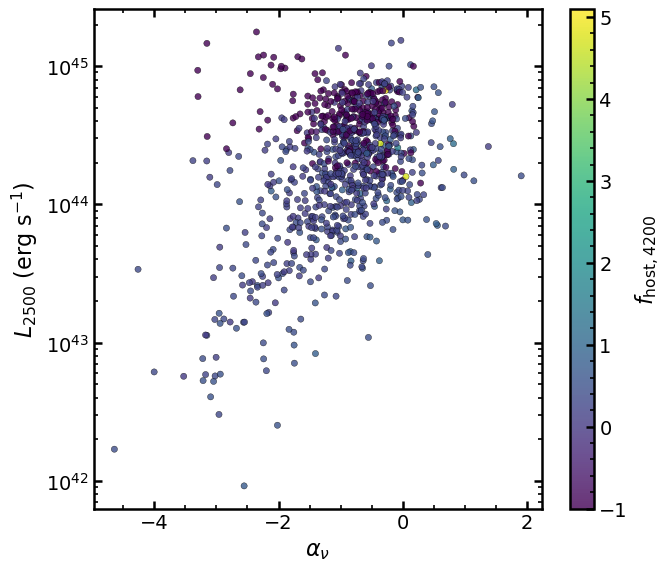

Saved plots/hubble/test/L2500_vs_alpha_nu.png


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt
import os

def plot_L2500_vs_alpha_nu(df_agn, cosmo_model, z_pivot_agn,
                           plot_path='plots/hubble', show=False, debias=True, dms=None):
    d = df_agn.copy()

    # --- Build cosmology ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=70, Om0=0.3, w0=-1)   # set defaults if no posterior
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    else:
        raise ValueError("Add support for your cosmology model here")

    # --- Absolute magnitudes & debias ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        M2500 -= dm_interp(pts)
    else:
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value

    logL2500 = -0.4 * (M2500 - 90.0)
    L2500 = 10**logL2500

    # --- Add computed L back into df for masking ---
    d = d.assign(L2500=L2500, logL2500=logL2500)

    # --- Now apply mask on f_host_4200 ---
    d = d[d['f_host_4200'] > -2].reset_index(drop=True)

    # --- Scatter plot ---
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(d['alpha_nu'], d['L2500'], c=d['f_host_4200'], cmap='viridis',
                    s=20, alpha=0.8, edgecolor='k', lw=0.3)

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label(r'$f_{\rm host,4200}$')

    ax.set_xlabel(r'$\alpha_\nu$')
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_yscale('log')

    plt.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    outfile = os.path.join(plot_path, "L2500_vs_alpha_nu.png")
    plt.savefig(outfile, dpi=300)
    if show:
        plt.show()
    plt.close()
    print(f"Saved {outfile}")

plot_L2500_vs_alpha_nu(df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5, debias=True, dms=dmag_corr, show=True, plot_path='plots/hubble/test')

In [91]:
df_agn.loc[df_agn['alpha_lambda'] > 0].sort_values(by='alpha_lambda', ascending=False)
df_agn.loc[df_agn['alpha_lambda'] > 0].sort_values(by='alpha_lambda', ascending=False).to_csv('alpha_lambda_gt0.csv', index=False)

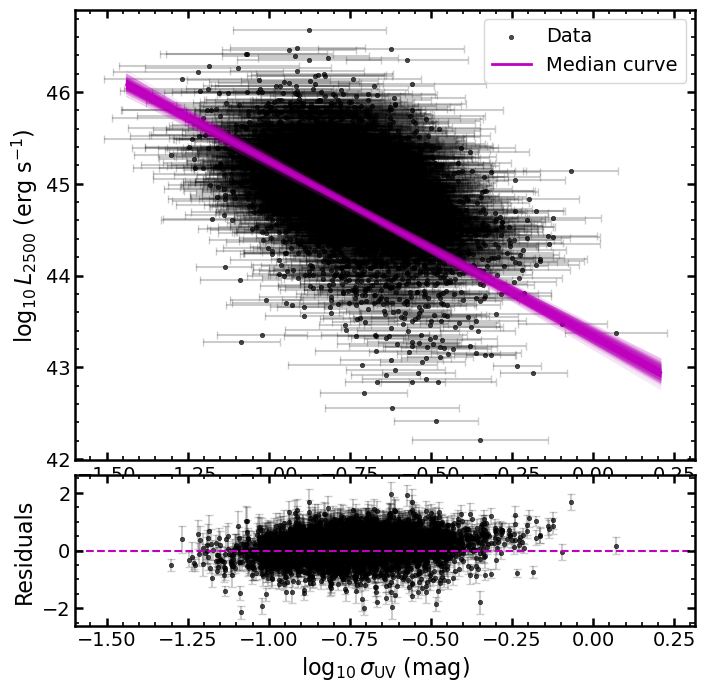

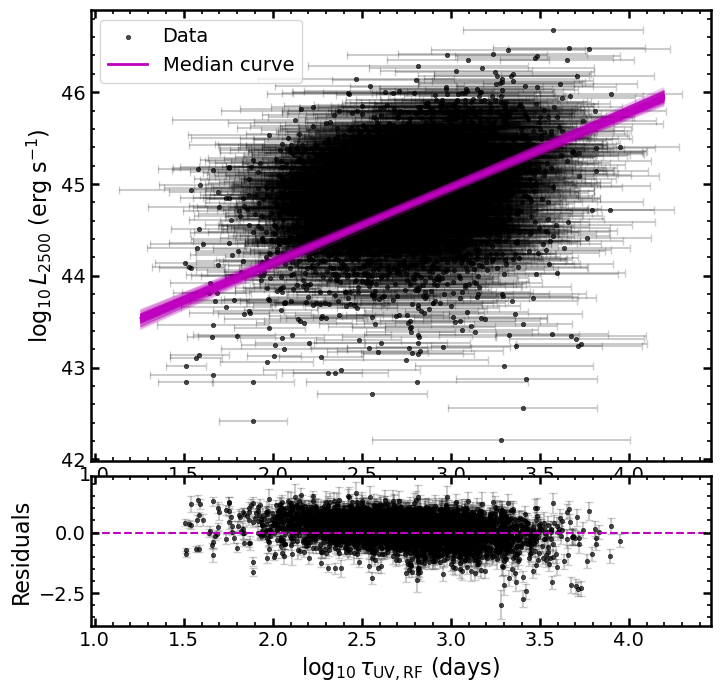

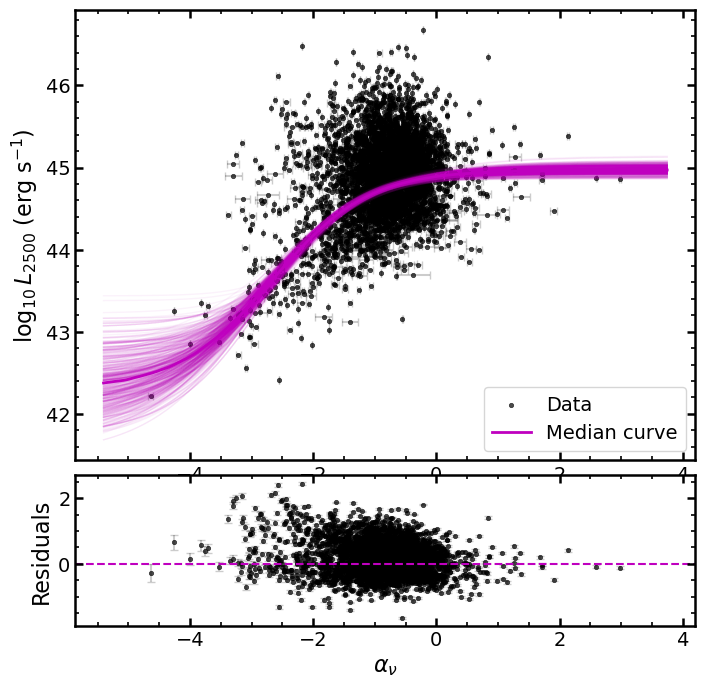

In [41]:
def plot_predicted_L2500_vs_raw_observables(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, max_lines=600
):
    """
    Make 3 figures with one line per posterior sample (low alpha):
      1) log10 L2500 vs log_sigma_UV   (slope ~ -0.4*alpha)
      2) log10 L2500 vs log_tau_UV_RF  (slope ~ -0.4*beta)
      3) log10 L2500 vs alpha_nu       (curved: -0.4*gamma * logistic(alpha_nu))
    Other observables are fixed to their sample-median values.
    Residual panels compare data to the *median* model curve in each panel.
    """
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Param indexing ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots arrays once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    # Convenience local getters
    def _get(name):  return agn_model_pidx[name]
    def _oidx(name): return agn_model_oidx[name]
    def _eidx(name): return agn_model_eidx[name]

    # --- Posterior medians (used for cosmology and for "fixed" values of the other observables) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    median_params_arr = agn_model_pack_params(results)

    # Cosmology
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # Data: log10 L_2500
    actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # Fixed values (medians of the dataset) for the "other" observables in each panel
    log_sigma_fixed = np.median(d['log_sigma_UV'])
    log_tau_fixed   = np.median(d['log_tau_UV_RF'])
    alpha_nu_fixed  = np.median(d['alpha_nu'])

    # Errors for x (data)
    log_sigma_err = d['log_sigma_UV_err']
    log_tau_err   = d['log_tau_UV_RF_err']
    alpha_nu_err  = d['alpha_nu_err']

    # Pivots
    log_sigma_p = agn_pivot_arr[_oidx("log_sigma_UV")]
    log_tau_p   = agn_pivot_arr[_oidx("log_tau_UV_RF")]

    # Helper: logistic and derivative
    def _logistic(alpha_nu, k_logistic, alpha_nu_pivot):
        z = k_logistic * (alpha_nu - alpha_nu_pivot)
        return 2*expit(z) - 1

    def _logistic_deriv(alpha_nu, k_logistic, alpha_nu_pivot):
        z = k_logistic * (alpha_nu - alpha_nu_pivot)
        sig = expit(z)
        return k_logistic * sig * (1.0 - sig)

    # --- Panel builders -------------------------------------------------------

    def _draw_panel(
        xname, xgrid, xdata, xerr,
        vary_which="sigma",  # "sigma" | "tau" | "alpha_nu"
        fname="panel.png",
        xlabel=r"$x$",
    ):
        """
        Draw one panel: many sample lines (low alpha) + data scatter + residuals.
        For each sample, the prediction is:
          logL = -0.4*(M0 - 90) - 0.4 * [alpha*(logσ-logσp) + beta*(logτ-logτp) + gamma*logistic(α_ν)]
        where only one observable varies along xgrid; the others are fixed to medians.
        """
        color = 'm'
        import matplotlib.gridspec as gridspec
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)

        # Precompute sample curves for uncertainty envelope at each x (for residual error bars)
        ygrid_samples = []

        # Draw sample lines
        nplot = min(max_lines, flat_samples.shape[0])
        for i, s in enumerate(flat_samples):
            sample_params = {k: s[param_indices[k]] for k in model_labels}
            aparr = agn_model_pack_params(sample_params)

            M0       = aparr[_get("M0_agn")]
            alpha    = aparr[_get("alpha_agn")]
            beta     = aparr[_get("beta_agn")]
            gamma    = aparr[_get("gamma_agn")]
            klog     = aparr[_get("k_logistic")]
            a_pivot  = aparr[_get("alpha_nu_pivot")]

            # Choose which observable varies along xgrid
            if vary_which == "sigma":
                log_sigma = xgrid
                log_tau   = log_tau_fixed
                a_nu      = alpha_nu_fixed
            elif vary_which == "tau":
                log_sigma = log_sigma_fixed
                log_tau   = xgrid
                a_nu      = alpha_nu_fixed
            elif vary_which == "alpha_nu":
                log_sigma = log_sigma_fixed
                log_tau   = log_tau_fixed
                a_nu      = xgrid
            else:
                raise ValueError("vary_which must be 'sigma', 'tau', or 'alpha_nu'.")

            # Build model in log space along the grid
            xlog_combo = (
                alpha * (log_sigma - log_sigma_p)
                + beta  * (log_tau   - log_tau_p)
                + gamma * _logistic(a_nu, klog, a_pivot)
            )
            ygrid = -0.4 * (M0 - 90.0) - 0.4 * xlog_combo
            ygrid_samples.append(ygrid)

            # Draw one line per sample (alpha transparency)
            if i < nplot:
                ax.plot(xgrid, ygrid, color=color, alpha=0.05, lw=1.0, zorder=-6)

        ygrid_samples = np.asarray(ygrid_samples)  # (nsamp, ngrid)
        ygrid_med  = np.median(ygrid_samples, axis=0)
        ygrid_low  = np.percentile(ygrid_samples, 16, axis=0)
        ygrid_high = np.percentile(ygrid_samples, 84, axis=0)

        # Residuals w.r.t. the median curve evaluated at data x
        from scipy.interpolate import interp1d
        f_med = interp1d(xgrid, ygrid_med, bounds_error=False, fill_value='extrapolate')
        y_model_at_data = f_med(xdata)
        residuals = actual_logL2500 - y_model_at_data

        # y-uncertainty from sample spread at each data x
        f_low  = interp1d(xgrid, ygrid_low,  bounds_error=False, fill_value='extrapolate')
        f_high = interp1d(xgrid, ygrid_high, bounds_error=False, fill_value='extrapolate')
        obs_err = 0.5 * (f_high(xdata) - f_low(xdata))

        # Propagate x-uncertainty into y using the *median* slope for that panel
        alpha_med = median_params_arr[_get("alpha_agn")]
        beta_med  = median_params_arr[_get("beta_agn")]
        gamma_med = median_params_arr[_get("gamma_agn")]
        klog_med  = median_params_arr[_get("k_logistic")]
        a_piv_med = median_params_arr[_get("alpha_nu_pivot")]

        if vary_which == "sigma":
            dydx = -0.4 * alpha_med                    # d logL / d (logσ)
        elif vary_which == "tau":
            dydx = -0.4 * beta_med                     # d logL / d (logτ)
        else:  # alpha_nu
            dlogistic = _logistic_deriv(xdata, klog_med, a_piv_med)
            dydx = -0.4 * gamma_med * dlogistic        # d logL / d (alpha_nu)

        propagated_err = np.abs(dydx) * xerr
        total_err = np.sqrt(obs_err**2 + propagated_err**2)

        # --- Draw data (in log space on y; x is linear in the raw variable) ---
        ax.scatter(xdata, actual_logL2500, label='Data',
                   s=10, alpha=0.7, edgecolor='k', facecolor='k', lw=0.5, zorder=-8)
        ax.errorbar(xdata, actual_logL2500, xerr=xerr,
                    fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k', zorder=-9)

        # Optional: median curve on top for reference
        ax.plot(xgrid, ygrid_med, color=color, lw=2.0, zorder=-5, label='Median curve')

        ax.set_ylabel(r'$\log_{10} L_{2500}$ (erg s$^{-1}$)')
        ax.legend(loc='best')

        # Residuals
        ax_res.scatter(xdata, residuals, s=10, alpha=0.7,
                       edgecolor='k', facecolor='k', lw=0.5, zorder=-10)
        ax_res.errorbar(xdata, residuals, yerr=total_err,
                        fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k', zorder=-11)
        ax_res.axhline(0, color=color, linestyle='--', zorder=-9)
        ax_res.set_ylabel('Residuals')
        ax_res.set_xlabel(xlabel)

        # Save
        os.makedirs(plot_path, exist_ok=True)
        plt.setp(ax.get_xticklabels(), visible=True)  # x is linear here
        plt.savefig(os.path.join(plot_path, fname), dpi=300)
        if show:
            plt.show()
        plt.close()

    # --- Build sensible grids spanning the data range with padding ---
    pad_sigma = 0.1 * (d['log_sigma_UV'].max() - d['log_sigma_UV'].min() + 1e-6)
    pad_tau   = 0.1 * (d['log_tau_UV_RF'].max() - d['log_tau_UV_RF'].min() + 1e-6)
    pad_an    = 0.1 * (d['alpha_nu'].max() - d['alpha_nu'].min() + 1e-6)

    grid_sigma = np.linspace(d['log_sigma_UV'].min() - pad_sigma, d['log_sigma_UV'].max() + pad_sigma, 200)
    grid_tau   = np.linspace(d['log_tau_UV_RF'].min() - pad_tau, d['log_tau_UV_RF'].max() + pad_tau, 200)
    grid_an    = np.linspace(d['alpha_nu'].min() - pad_an, d['alpha_nu'].max() + pad_an, 200)

    # --- Draw each panel ---
    _draw_panel(
        xname='log_sigma_UV', xgrid=grid_sigma,
        xdata=d['log_sigma_UV'].values, xerr=log_sigma_err.values,
        vary_which="sigma",
        fname="predicted_logL2500_vs_logsigma_samples.png",
        xlabel=r'$\log_{10}\sigma_{\mathrm{UV}}$ (mag)'
    )

    _draw_panel(
        xname='log_tau_UV_RF', xgrid=grid_tau,
        xdata=d['log_tau_UV_RF'].values, xerr=log_tau_err.values,
        vary_which="tau",
        fname="predicted_logL2500_vs_logtau_samples.png",
        xlabel=r'$\log_{10}\tau_{\mathrm{UV,RF}}$ (days)'
    )

    _draw_panel(
        xname='alpha_nu', xgrid=grid_an,
        xdata=d['alpha_nu'].values, xerr=alpha_nu_err.values,
        vary_which="alpha_nu",
        fname="predicted_logL2500_vs_alphanu_samples.png",
        xlabel=r'$\alpha_\nu$'
    )

plot_predicted_L2500_vs_raw_observables(
    flat_samples, df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5,
    show=True, plot_path='plots/hubble/test')